(8208, 10)
(5472, 10)
(10944, 4)


C:\Users\rabia\AppData\Local\Temp\ipykernel_21796\3860769034.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=75, fontsize = 14)
C:\Users\rabia\AppData\Local\Temp\ipykernel_21796\3860769034.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=75, fontsize = 14)
C:\Users\rabia\AppData\Local\Temp\ipykernel_21796\3860769034.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=75, fontsize = 14)


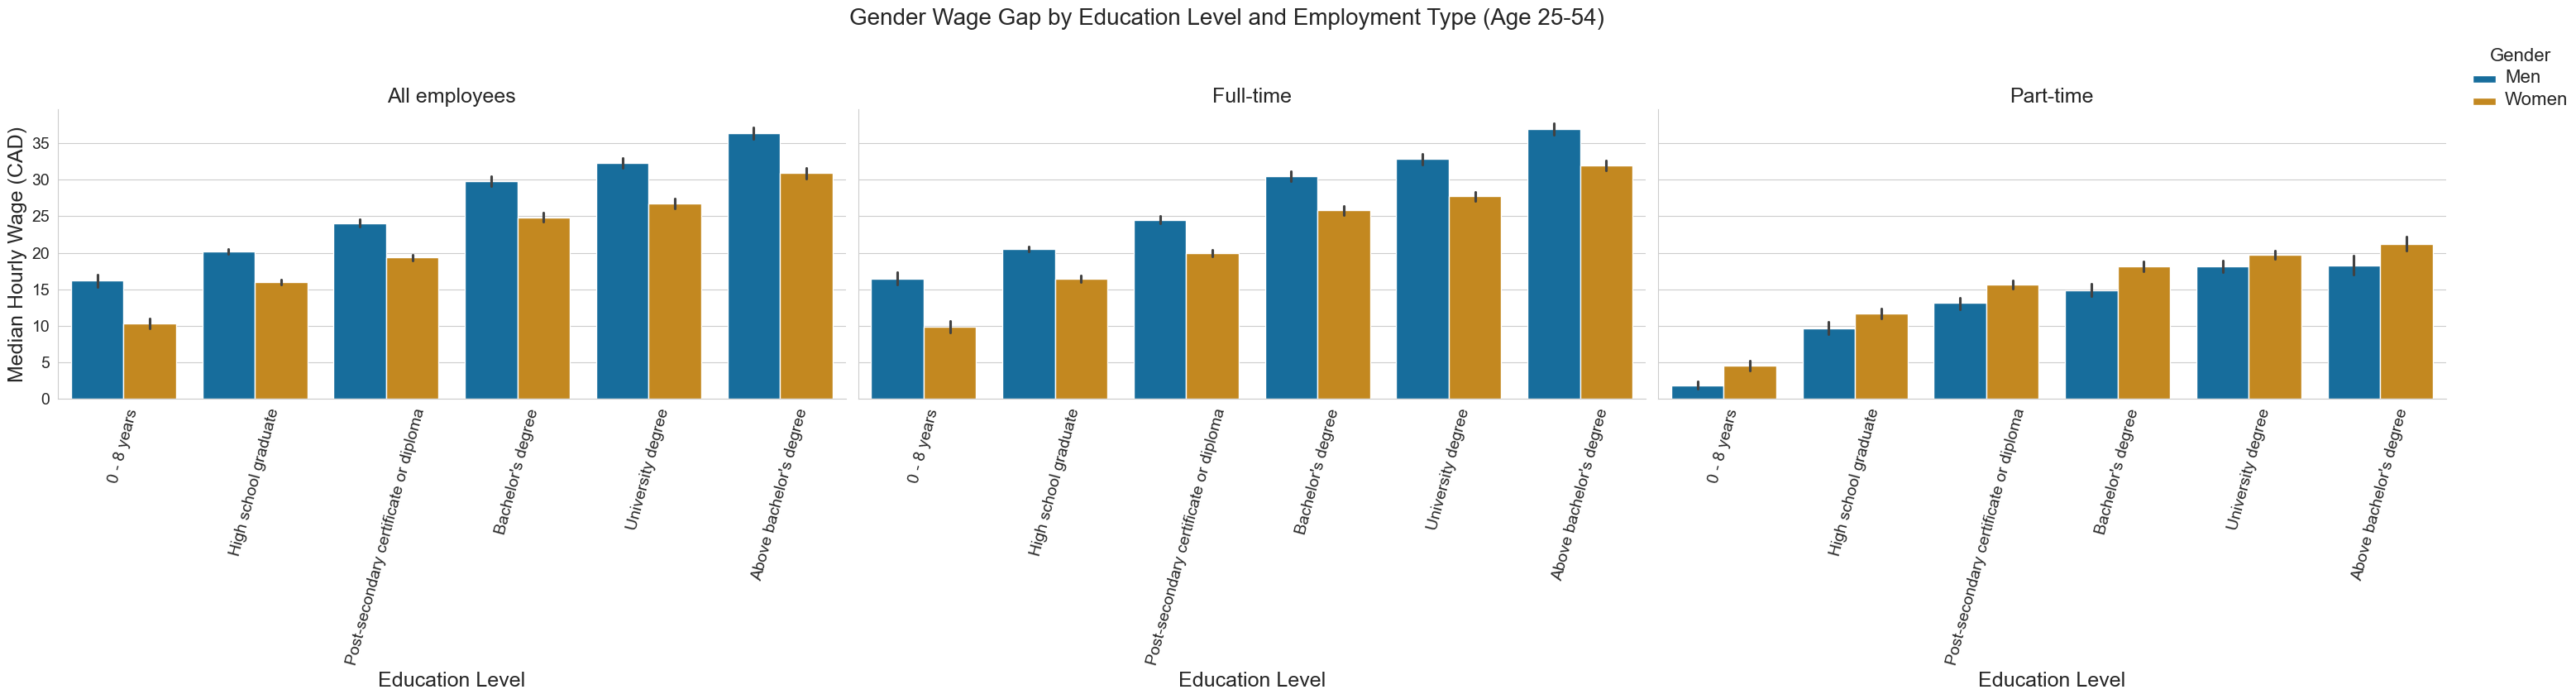

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load CSV file
df = pd.read_csv("C:/Users/rabia/Desktop/UofT_DSI_Certificate/DSI-VisualizationModule-Assignment3-SourceData/img-wage-rate-by-edu-age-sex-ft-pt-ca-on-2006-24.csv")

# Cleaning columns 
df['EDUCATION'] = df['EDUCATION'].str.strip().str.replace('’', "'")
df['WAGE RATE'] = df['WAGE RATE'].str.strip()
df['AGE GROUP'] = df['AGE GROUP'].str.strip()
df['TYPE OF WORK'] = df['TYPE OF WORK'].str.strip()

# Filter for median wage and age 25–54
df_filtered = df[
    (df['WAGE RATE'].str.contains('Median')) &
    (df['AGE GROUP'] == '25 - 54')
]

print(df_filtered.shape) # To see the size of the filtered data

# Select a few education levels to keep it readable
edu_levels = [
    '0 - 8 years',
    'High school graduate',
    'Post-secondary certificate or diploma',
    "Bachelor's degree",
    'University degree',
    "Above bachelor's degree"
]
df_filtered = df_filtered[df_filtered['EDUCATION'].isin(edu_levels)]

print(df_filtered.shape) # To see the size of the filtered data after selected education levels

# Clean up column names for plotting
df_filtered = df_filtered.rename(columns={' Men': 'Men', ' Women': 'Women'})

# Reshape data from wide to long format
df_long = df_filtered.melt(
    id_vars=['EDUCATION','TYPE OF WORK'],
    value_vars=['Men', 'Women'],
    var_name='Gender',
    value_name='Wage'
)

print(df_long.shape) # To see the size of the data after converting it to long format

# Sort education levels in logical order
df_long['EDUCATION'] = pd.Categorical(df_long['EDUCATION'], categories=edu_levels, ordered=True)
df_long.sort_values(by='EDUCATION', inplace=True)

# Plot with seaborn
sns.set_style("whitegrid")
barplot = sns.catplot(data=df_long, 
            x='EDUCATION', 
            y='Wage', 
            hue='Gender',
            col = 'TYPE OF WORK',
            kind = 'bar',
            height = 8, 
            aspect = 1.2, 
            palette = "colorblind") # This line enables colorblind-friendly colors

# Set title names and font sizes
barplot.set_titles("{col_name}", size = 18)
barplot.set_axis_labels("Education Level", "Median Hourly Wage (CAD)", fontsize = 18)
barplot.fig.suptitle("Gender Wage Gap by Education Level and Employment Type (Age 25-54)", y=1.05, fontsize = 20)

# Fix xtick labels with rotation anf font size
for ax in barplot.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=75, fontsize = 14)
    ax.tick_params(axis='y', labelsize=14)

# Move legend to top right
barplot._legend.set_loc('upper left')
barplot._legend.set_bbox_to_anchor((1, 1)) 

# Set font size of legend title
barplot._legend.get_title().set_fontsize(16)

# Set font size of legend entries
for text in barplot._legend.texts:
    text.set_fontsize(16)

# Save plot
barplot.savefig("gender_wage_gap_education_python.png", dpi=300, bbox_inches='tight')

# Print plot
plt.tight_layout()
plt.show()